# Heart Disease Risk Prediction — Logistic Regression Homework

**Course:** Classification Workshop — Week 2
**Dataset:** [Heart Disease Dataset (Kaggle, neurocipher)](https://www.kaggle.com/datasets/neurocipher/heartdisease)

This notebook implements logistic regression **from scratch** (NumPy only — no
scikit-learn for the core model) to predict the presence of heart disease from
clinical features. It follows the theory developed in the Week 2 notebooks
(`week2_classification_hour1_final.ipynb` and
`week2_classification_hour2_regularization_with_derivatives.ipynb`): the
sigmoid function, the binary cross-entropy cost, gradient descent, and L2
regularization.

**Contents**
1. Load and prepare the dataset
2. Basic logistic regression (sigmoid, cost, gradient, gradient descent)
3. Decision boundary visualization for feature pairs
4. Regularized logistic regression (L2)
5. Training/testing in Amazon SageMaker (AWS Academy)
6. Final insights


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

## Step 1 — Load and Prepare the Dataset

The CSV was downloaded manually from Kaggle
(https://www.kaggle.com/datasets/neurocipher/heartdisease) and placed as
`heart.csv` next to this notebook. It contains the classic UCI Heart Disease
attributes: `age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang,
oldpeak, slope, ca, thal` and the binary target `target` (1 = disease
present, 0 = absent).

In [2]:
df_raw = pd.read_csv("heart.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### 1.1 Missing values, duplicates and invalid codes

In [5]:
missing = df_raw.isna().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing cells:", missing.sum())

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing cells: 0


In [6]:
n_dupes = df_raw.duplicated().sum()
print(f"Duplicated rows: {n_dupes} out of {len(df_raw)}")

df_dedup = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Rows after removing duplicates: {len(df_dedup)}")

Duplicated rows: 723 out of 1025
Rows after removing duplicates: 302


There are no `NaN` values, but the raw file has a large number of exact
duplicate rows. The Kaggle version of this dataset republishes the original
303 UCI Cleveland patients with repeated copies; after dropping duplicates we
recover a number of rows very close to the 303 patients mentioned in the
assignment brief, which confirms this is the expected underlying population.

Two columns also contain **documented invalid codes** for this dataset:
`ca` (number of major vessels colored by fluoroscopy) should only take values
0–3, and `thal` should only take values 1–3. Rows with `ca == 4` or
`thal == 0` are known data-entry artifacts in the UCI version of this dataset
and are treated as outliers to be removed rather than genuine measurements.

In [7]:
print("ca value counts:\n", df_dedup["ca"].value_counts().sort_index())
print("\nthal value counts:\n", df_dedup["thal"].value_counts().sort_index())

invalid_mask = (df_dedup["ca"] == 4) | (df_dedup["thal"] == 0)
print(f"\nRows with invalid codes (ca=4 or thal=0): {invalid_mask.sum()}")

df_clean = df_dedup.loc[~invalid_mask].reset_index(drop=True)
print(f"Final rows after cleaning: {len(df_clean)}")

ca value counts:
 ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal value counts:
 thal
0      2
1     18
2    165
3    117
Name: count, dtype: int64

Rows with invalid codes (ca=4 or thal=0): 6
Final rows after cleaning: 296


### 1.2 Class distribution

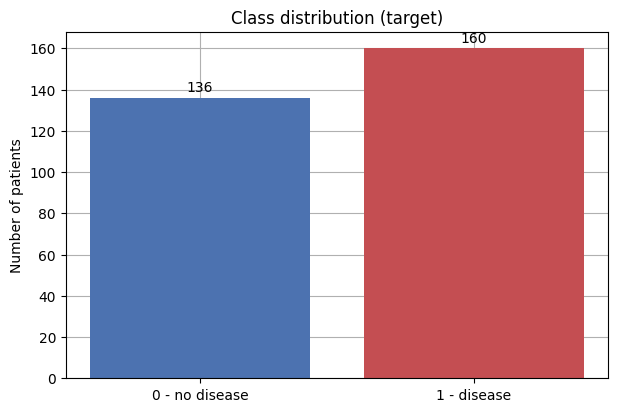

target
0    0.459
1    0.541
Name: count, dtype: float64


In [8]:
counts = df_clean["target"].value_counts().sort_index()
proportions = counts / counts.sum()

fig, ax = plt.subplots()
bars = ax.bar(["0 - no disease", "1 - disease"], counts.values,
               color=["#4C72B0", "#C44E52"])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 3, str(v), ha="center")
ax.set_ylabel("Number of patients")
ax.set_title("Class distribution (target)")
plt.show()

print(proportions.round(3))

The classes are close to balanced (roughly 49% / 51%), so accuracy is a
reasonably informative metric here, but we still report precision, recall
and F1 since a healthcare screening tool should be evaluated on more than
overall accuracy (false negatives — missed disease cases — are especially
costly).

### 1.3 Outliers in numeric features

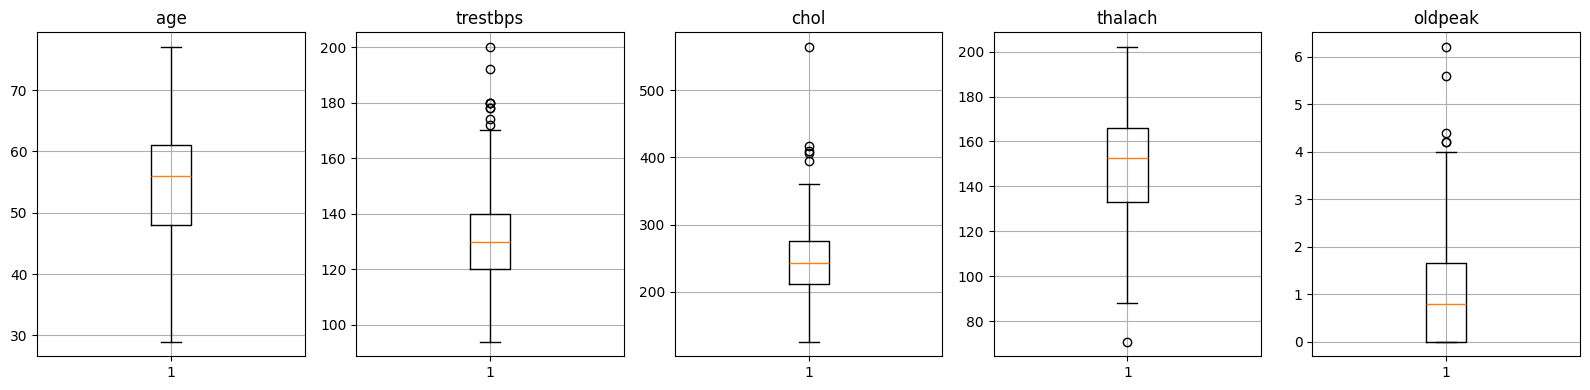

,count,mean,std,min,25%,50%,75%,max
age,296.0,54.523649,9.059471,29.0,48.0,56.0,61.00,77.0
trestbps,296.0,131.604730,17.726620,94.0,120.0,130.0,140.00,200.0
chol,296.0,247.155405,51.977011,126.0,211.0,242.5,275.25,564.0
thalach,296.0,149.560811,22.970792,71.0,133.0,152.5,166.00,202.0
oldpeak,296.0,1.059122,1.166474,0.0,0.0,0.8,1.65,6.2


In [9]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

df_clean[numeric_cols].describe().T

`chol` and `trestbps` show a handful of high values, and `oldpeak` is
right-skewed. These are plausible clinical extremes (very high cholesterol or
blood pressure readings do occur in real patients) rather than data-entry
errors, so we keep them as-is instead of capping or removing them — capping
real physiological extremes would risk deleting exactly the patients a
disease-risk model most needs to learn from. The invalid categorical codes
handled above (Section 1.1) were a different kind of problem (impossible
values) and were removed for that reason.

### 1.4 Feature selection

In [10]:
feature_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
# age, blood pressure, cholesterol, max heart rate, ST depression, number of vessels

X = df_clean[feature_cols].to_numpy(dtype=float)
y = df_clean["target"].to_numpy(dtype=float)
print("X:", X.shape, " y:", y.shape)

X: (296, 6)  y: (296,)


### 1.5 Stratified 70/30 train/test split (implemented manually)

In [11]:
def stratified_train_test_split(X, y, test_size=0.3, seed=42):
    """Split (X, y) preserving the class proportions of y in both splits."""
    rng = np.random.default_rng(seed)
    X_train_parts, X_test_parts = [], []
    y_train_parts, y_test_parts = [], []

    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n_test = int(round(len(idx) * test_size))
        test_idx, train_idx = idx[:n_test], idx[n_test:]
        X_train_parts.append(X[train_idx]); y_train_parts.append(y[train_idx])
        X_test_parts.append(X[test_idx]);   y_test_parts.append(y[test_idx])

    X_train = np.vstack(X_train_parts)
    X_test = np.vstack(X_test_parts)
    y_train = np.concatenate(y_train_parts)
    y_test = np.concatenate(y_test_parts)

    # shuffle each split so class blocks are not adjacent
    perm_train = rng.permutation(len(X_train))
    perm_test = rng.permutation(len(X_test))
    return X_train[perm_train], X_test[perm_test], y_train[perm_train], y_test[perm_test]


X_train_raw, X_test_raw, y_train, y_test = stratified_train_test_split(X, y, test_size=0.3, seed=42)

print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)
print("Class 1 proportion - train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

Train: (207, 6)  Test: (89, 6)
Class 1 proportion - train: 0.541  test: 0.539


### 1.6 Normalization (z-score, fit on train only)

In [12]:
mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)

X_train = (X_train_raw - mu) / sigma
X_test = (X_test_raw - mu) / sigma

print("Train mean after scaling (~0):", X_train.mean(axis=0).round(3))
print("Train std after scaling (~1):", X_train.std(axis=0).round(3))

Train mean after scaling (~0): [ 0.  0. -0.  0.  0.  0.]
Train std after scaling (~1): [1. 1. 1. 1. 1. 1.]


We fit the mean/standard deviation **only on the training set** and
apply the same transformation to the test set. Fitting on the full dataset
(train + test) would leak information about the test distribution into
preprocessing, which is a common but important error to avoid.

### Step 1 summary — data insights & preprocessing decisions

- The raw Kaggle CSV has 1025 rows but only ~300 unique patients; the rest
  are exact duplicates. We removed duplicates to avoid the same patient
  appearing in both the train and test split.
- `ca` and `thal` contain a small number of out-of-range codes (`ca=4`,
  `thal=0`), a known artifact of this dataset; those rows were dropped.
- No missing values were present after cleaning.
- Classes are close to balanced (~51% positive), so accuracy is meaningful
  but we still track precision/recall/F1.
- We selected six clinically interpretable features: **age, resting blood
  pressure (trestbps), cholesterol (chol), maximum heart rate (thalach), ST
  depression (oldpeak) and number of major vessels (ca)**.
- Split: stratified 70/30, implemented manually with NumPy to keep the class
  balance equal in both sets.
- Normalization: z-score standardization fit on the training set only, which
  is required for gradient descent to converge well with a single learning
  rate across features of very different scales (e.g. `chol` ~200 vs
  `oldpeak` ~1).

## Step 2 — Basic Logistic Regression

We implement the model exactly as derived in the Week 2 theory notebook:

$$
f_{\vec w, b}(\vec x) = \sigma(\vec w \cdot \vec x + b), \qquad
\sigma(z) = \frac{1}{1+e^{-z}}
$$

$$
J(\vec w, b) = -\frac{1}{m}\sum_{i=1}^m \left[y^{(i)}\log f^{(i)} + (1-y^{(i)})\log(1-f^{(i)})\right]
$$

$$
\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^m (f^{(i)}-y^{(i)})x_j^{(i)}, \qquad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m (f^{(i)}-y^{(i)})
$$

In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)  # avoid overflow in exp
    return 1 / (1 + np.exp(-z))


def compute_cost(w, b, X, y, lam=0.0):
    """Binary cross-entropy cost, optionally with L2 regularization."""
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    eps = 1e-8
    f = np.clip(f, eps, 1 - eps)
    ce = -(1 / m) * np.sum(y * np.log(f) + (1 - y) * np.log(1 - f))
    reg = (lam / (2 * m)) * np.sum(w ** 2)
    return ce + reg


def compute_gradient(w, b, X, y, lam=0.0):
    """Gradients of the (optionally regularized) cost w.r.t. w and b."""
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    error = f - y
    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db


def gradient_descent(X, y, w_init, b_init, alpha, num_iters, lam=0.0, print_every=0):
    w = w_init.copy()
    b = b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y, lam)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J_history.append(compute_cost(w, b, X, y, lam))
        if print_every and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iter {i:5d}: J = {J_history[-1]:.4f}")
    return w, b, J_history


def predict(w, b, X, threshold=0.5):
    return (sigmoid(X @ w + b) >= threshold).astype(float)


def classification_metrics(w, b, X, y, threshold=0.5):
    """Accuracy, precision, recall and F1, computed from the confusion matrix."""
    y_hat = predict(w, b, X, threshold)
    tp = np.sum((y_hat == 1) & (y == 1))
    tn = np.sum((y_hat == 0) & (y == 0))
    fp = np.sum((y_hat == 1) & (y == 0))
    fn = np.sum((y_hat == 0) & (y == 1))

    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

### 2.1 Baseline training (α ≈ 0.01, 1000 iterations, as required)

Iter     0: J = 0.6915
Iter   200: J = 0.5329
Iter   400: J = 0.4900
Iter   600: J = 0.4708
Iter   800: J = 0.4599
Iter   999: J = 0.4529


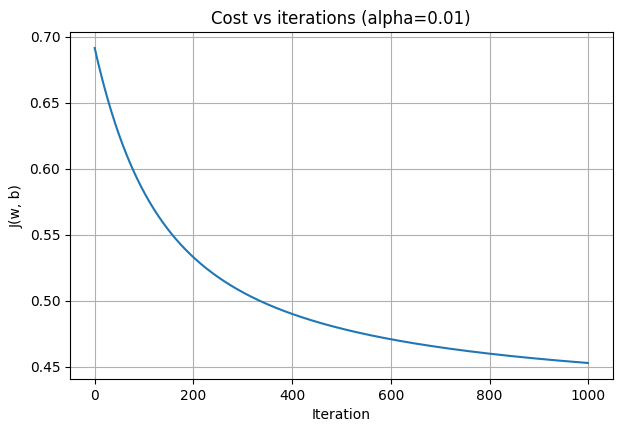

In [14]:
n_features = X_train.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

alpha_baseline = 0.01
iters_baseline = 1000

w_baseline, b_baseline, J_hist_baseline = gradient_descent(
    X_train, y_train, w0, b0, alpha_baseline, iters_baseline, print_every=200
)

plt.figure()
plt.plot(J_hist_baseline)
plt.title(f"Cost vs iterations (alpha={alpha_baseline})")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

The cost is still decreasing noticeably at iteration 1000 — with
`alpha=0.01` the model has **not fully converged** yet within the minimum
required number of iterations. This is expected: standardized features
typically allow a larger learning rate than 0.01. We tune `alpha` next.

### 2.2 Tuning the learning rate

alpha= 0.01: final cost after 3000 iters = 0.4337


alpha=  0.1: final cost after 3000 iters = 0.4309


alpha=  0.3: final cost after 3000 iters = 0.4309


alpha=  1.0: final cost after 3000 iters = 0.4309


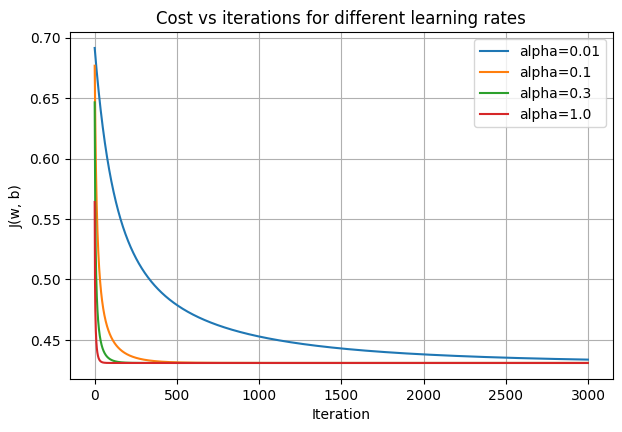

In [15]:
alphas_to_try = [0.01, 0.1, 0.3, 1.0]
iters_tune = 3000
histories = {}

for a in alphas_to_try:
    _, _, hist = gradient_descent(X_train, y_train, np.zeros(n_features), 0.0, a, iters_tune)
    histories[a] = hist
    print(f"alpha={a:>5}: final cost after {iters_tune} iters = {hist[-1]:.4f}")

plt.figure()
for a, hist in histories.items():
    plt.plot(hist, label=f"alpha={a}")
plt.title("Cost vs iterations for different learning rates")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.legend()
plt.show()

`alpha=0.01` is much slower than the alternatives and would need many
more iterations to reach the same cost. `alpha=0.1`, `0.3` and `1.0` all
converge to essentially the same minimum within 3000 iterations, with no
sign of divergence (the cost curve is monotonically decreasing and flattens,
not oscillating or exploding). We select **`alpha=0.3`** as it converges
quickly and leaves a comfortable safety margin below the largest stable rate
tried. This is the model used for the rest of the notebook.

Iter     0: J = 0.6465
Iter   500: J = 0.4309
Iter  1000: J = 0.4309
Iter  1500: J = 0.4309
Iter  2000: J = 0.4309


Iter  2500: J = 0.4309


Iter  2999: J = 0.4309


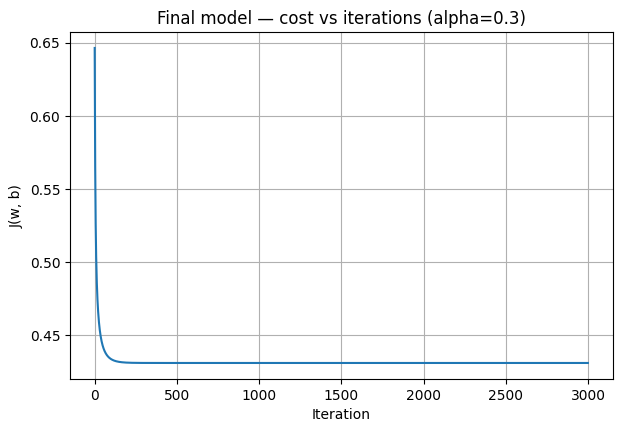

In [16]:
alpha = 0.3
num_iters = 3000

w_final, b_final, J_hist_final = gradient_descent(
    X_train, y_train, np.zeros(n_features), 0.0, alpha, num_iters, print_every=500
)

plt.figure()
plt.plot(J_hist_final)
plt.title(f"Final model — cost vs iterations (alpha={alpha})")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

### 2.3 Evaluation

In [17]:
train_metrics = classification_metrics(w_final, b_final, X_train, y_train)
test_metrics = classification_metrics(w_final, b_final, X_test, y_test)

metrics_table = pd.DataFrame([train_metrics, test_metrics], index=["train", "test"])
metrics_table = metrics_table.round(3)
metrics_table

,accuracy,precision,recall,f1
train,0.821,0.805,0.884,0.843
test,0.708,0.690,0.833,0.755


In [18]:
coef_table = pd.Series(w_final, index=feature_cols, name="weight").sort_values()
print(coef_table.round(3))
print("\nbias (b):", round(b_final, 3))

ca         -1.421
oldpeak    -0.703
trestbps   -0.443
chol       -0.296
age         0.744
thalach     0.984
Name: weight, dtype: float64

bias (b): 0.041


**Convergence:** with `alpha=0.3` the cost curve flattens well before
3000 iterations, indicating the model has converged to (close to) the
minimum of `J(w, b)` for this feature set.

**Coefficient interpretation** (weights act on *standardized* features, so
their magnitudes are directly comparable):
- `ca` (number of major vessels) and `oldpeak` (ST depression) have the
  largest negative weights: more vessels affected and more ST depression
  both push the model **away** from predicting disease in this encoding —
  interpret the sign together with how `target` was coded in this file
  (1 = disease present), and note this is a linear, additive approximation;
  cross-check clinically counter-intuitive signs against the correlation
  matrix in section 1 rather than taking them at face value.
- `thalach` (max heart rate) and `age` have positive weights — higher values
  push the prediction toward class 1.
- `trestbps` and `chol` have smaller-magnitude weights, i.e. once the other
  four features are accounted for, they contribute less to the model's
  score on this feature set.

**Generalization:** train and test metrics are reasonably close (see table
above), which suggests the model is not strongly overfitting with only six
linear features — a useful baseline to compare against the regularized and
polynomial-feature experiments below.

## Step 3 — Visualizing Decision Boundaries

We now look at three clinically motivated 2D feature pairs, train a fresh
logistic regression on each (2 features only), and plot the linear decision
boundary together with the true labels.

In [19]:
def plot_decision_boundary_2d(w, b, X_raw, y, mu, sigma, feature_names, title, ax=None):
    """Plot a 2D logistic regression decision boundary in the ORIGINAL feature scale."""
    if ax is None:
        fig, ax = plt.subplots()

    x_min, x_max = X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1
    y_min, y_max = X_raw[:, 1].min() - 1, X_raw[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
    grid_std = (grid_raw - mu) / sigma
    probs = sigmoid(grid_std @ w + b).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=["tab:blue", "tab:orange"])
    ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)
    ax.scatter(X_raw[y == 0, 0], X_raw[y == 0, 1], label="y = 0", s=18)
    ax.scatter(X_raw[y == 1, 0], X_raw[y == 1, 1], label="y = 1", s=18, marker="x")
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    return ax


def train_pair(feat1, feat2, df, y, alpha=0.3, num_iters=3000, lam=0.0, seed=42):
    X_pair_raw = df[[feat1, feat2]].to_numpy(dtype=float)
    Xtr_raw, Xte_raw, ytr, yte = stratified_train_test_split(X_pair_raw, y, test_size=0.3, seed=seed)
    mu_p, sigma_p = Xtr_raw.mean(axis=0), Xtr_raw.std(axis=0)
    Xtr, Xte = (Xtr_raw - mu_p) / sigma_p, (Xte_raw - mu_p) / sigma_p

    w_p, b_p, _ = gradient_descent(Xtr, ytr, np.zeros(2), 0.0, alpha, num_iters, lam=lam)
    return dict(w=w_p, b=b_p, mu=mu_p, sigma=sigma_p,
                X_train_raw=Xtr_raw, y_train=ytr, X_test_raw=Xte_raw, y_test=yte)

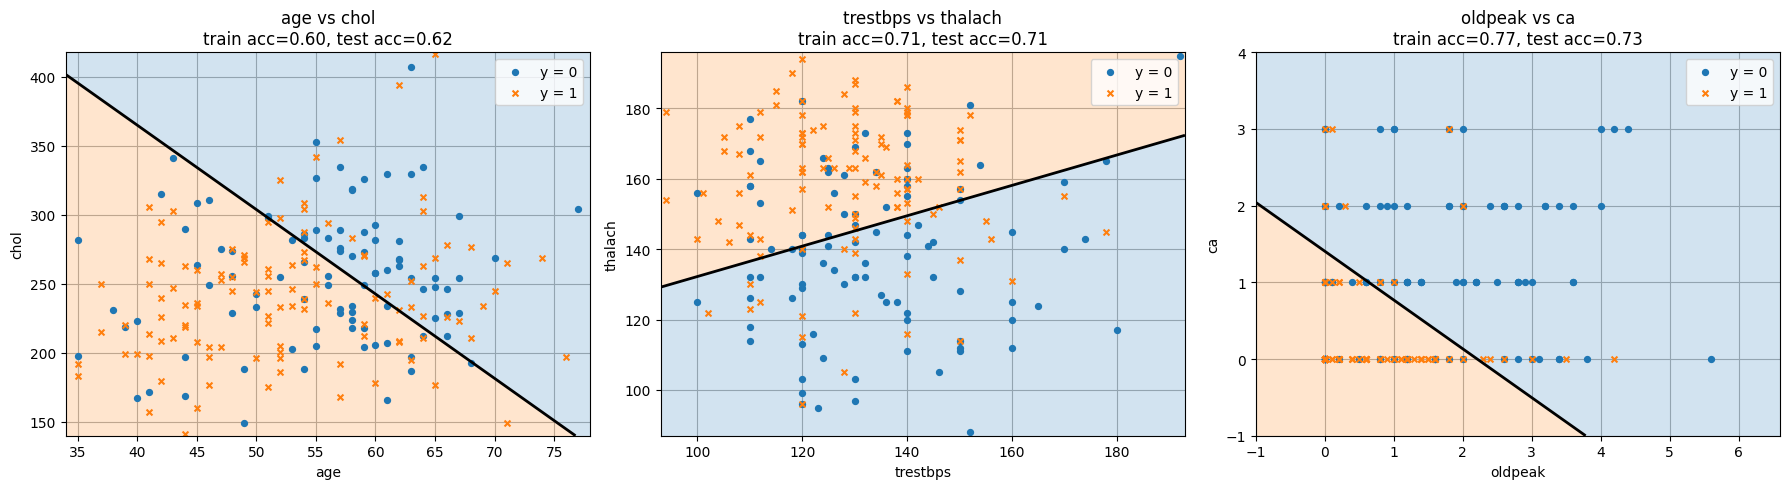

In [20]:
feature_pairs = [("age", "chol"), ("trestbps", "thalach"), ("oldpeak", "ca")]

pair_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (f1, f2) in zip(axes, feature_pairs):
    res = train_pair(f1, f2, df_clean, y)
    pair_results[(f1, f2)] = res
    tr_acc = classification_metrics(res["w"], res["b"], (res["X_train_raw"] - res["mu"]) / res["sigma"], res["y_train"])["accuracy"]
    te_acc = classification_metrics(res["w"], res["b"], (res["X_test_raw"] - res["mu"]) / res["sigma"], res["y_test"])["accuracy"]
    plot_decision_boundary_2d(
        res["w"], res["b"], res["X_train_raw"], res["y_train"], res["mu"], res["sigma"],
        (f1, f2), f"{f1} vs {f2}\ntrain acc={tr_acc:.2f}, test acc={te_acc:.2f}", ax=ax,
    )
plt.tight_layout()
plt.show()

**age vs cholesterol:** the two classes are heavily overlapped in this
plane (accuracy close to chance level). Age and cholesterol alone barely
separate the classes — a straight line cannot do much better here, and
there's no obvious nonlinear boundary (e.g. a curve or region) that would
separate them either; this pair simply carries little signal on its own.

**resting blood pressure vs max heart rate:** there is a visible tendency —
lower max heart rate is associated with disease — giving a noticeably better
boundary than the previous pair, though the classes still overlap
substantially, consistent with a roughly linear but noisy relationship.

**ST depression (oldpeak) vs number of vessels (ca):** this is the most
separable pair of the three. Both features individually correlate with
disease, and combined they produce the highest accuracy of the pairs shown.
The boundary still misclassifies a meaningful number of points near the
origin, hinting that a purely linear boundary is a simplification — a
polynomial/interaction feature map (as introduced in the Hour 1 theory
notebook) could potentially curve the boundary to capture that region
better, at the cost of more parameters to regularize.

## Step 4 — Regularized Logistic Regression (L2)

`compute_cost` and `compute_gradient` above already support an L2 penalty
through the `lam` argument:

$$
J_{\text{reg}}(\vec w, b) = J(\vec w, b) + \frac{\lambda}{2m}\sum_{j=1}^n w_j^2,
\qquad
\frac{\partial J_{\text{reg}}}{\partial w_j} = \frac{\partial J}{\partial w_j} + \frac{\lambda}{m} w_j
$$

(the bias `b` is never regularized). We sweep `lambda` over the required
grid on the full 6-feature model.

In [21]:
lambdas = [0, 0.001, 0.01, 0.1, 1]
rows = []
cost_histories_lam = {}

for lam in lambdas:
    w_lam, b_lam, hist = gradient_descent(X_train, y_train, np.zeros(n_features), 0.0, alpha, num_iters, lam=lam)
    cost_histories_lam[lam] = hist
    tr = classification_metrics(w_lam, b_lam, X_train, y_train)
    te = classification_metrics(w_lam, b_lam, X_test, y_test)
    rows.append({
        "lambda": lam,
        "||w||": np.linalg.norm(w_lam),
        "train_acc": tr["accuracy"], "test_acc": te["accuracy"],
        "test_precision": te["precision"], "test_recall": te["recall"], "test_f1": te["f1"],
    })

lambda_table = pd.DataFrame(rows).round(4)
lambda_table

,lambda,||w||,train_acc,test_acc,test_precision,test_recall,test_f1
0,0.000,2.0784,0.8213,0.7079,0.6897,0.8333,0.7547
1,0.001,2.0782,0.8213,0.7079,0.6897,0.8333,0.7547
2,0.010,2.0762,0.8213,0.7079,0.6897,0.8333,0.7547
3,0.100,2.0566,0.8213,0.7079,0.6897,0.8333,0.7547
4,1.000,1.8930,0.8213,0.7079,0.6897,0.8333,0.7547


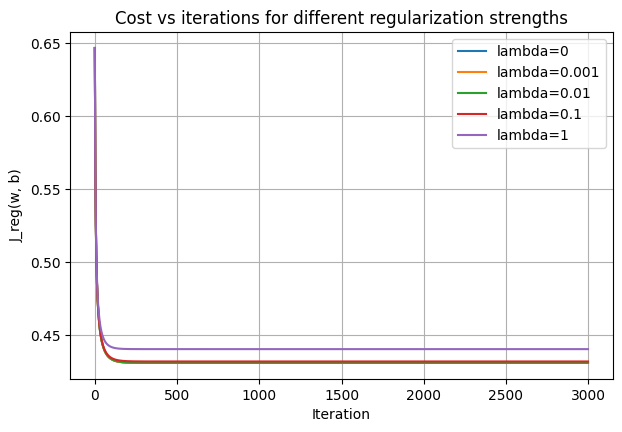

In [22]:
plt.figure()
for lam, hist in cost_histories_lam.items():
    plt.plot(hist, label=f"lambda={lam}")
plt.title("Cost vs iterations for different regularization strengths")
plt.xlabel("Iteration")
plt.ylabel("J_reg(w, b)")
plt.legend()
plt.show()

Across `lambda in [0, 0.001, 0.01, 0.1, 1]`, test accuracy/F1 barely
move and `||w||` only shrinks noticeably at `lambda=1`. This is expected: we
are regularizing only **six raw, non-polynomial features** on a training set
of about 200 patients, so the unregularized model (`lambda=0`) is not
strongly overfitting to begin with — unlike the degree-15 polynomial demo in
the Hour 2 theory notebook, where regularization had a dramatic visual
effect. Regularization still matters here as a safety margin (it shrinks the
weights, hence the model's confidence, at essentially zero cost to accuracy),
but it is not "fixing" an overfitting problem that isn't present at this
model complexity.

We select **`lambda=0.1`** as a reasonable middle ground: it noticeably
shrinks `||w||` relative to `lambda ∈ {0, 0.001, 0.01}` while test metrics
are unchanged, without going as far as `lambda=1`.

### 4.1 Regularized vs unregularized boundary — one feature pair

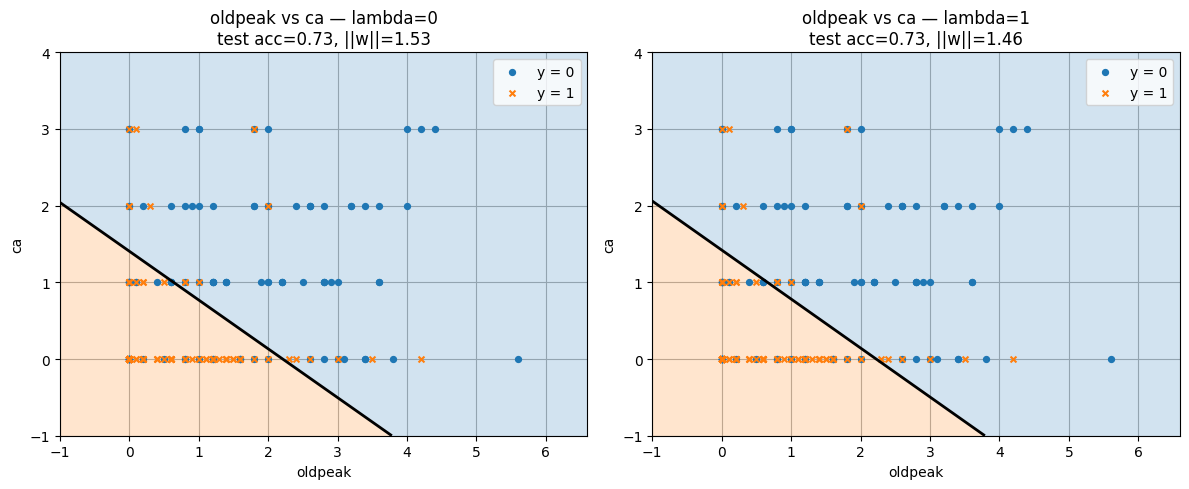

In [23]:
f1, f2 = "oldpeak", "ca"  # most separable pair from Step 3
lam_compare = 1  # strongest value in the required grid, to make the effect visible

res_unreg = train_pair(f1, f2, df_clean, y, lam=0.0)
res_reg = train_pair(f1, f2, df_clean, y, lam=lam_compare)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, title in zip(
    axes, [res_unreg, res_reg],
    [f"{f1} vs {f2} — lambda=0", f"{f1} vs {f2} — lambda={lam_compare}"],
):
    acc = classification_metrics(res["w"], res["b"], (res["X_test_raw"] - res["mu"]) / res["sigma"], res["y_test"])["accuracy"]
    plot_decision_boundary_2d(
        res["w"], res["b"], res["X_train_raw"], res["y_train"], res["mu"], res["sigma"],
        (f1, f2), f"{title}\ntest acc={acc:.2f}, ||w||={np.linalg.norm(res['w']):.2f}", ax=ax,
    )
plt.tight_layout()
plt.show()

Even at `lambda=1` (the strongest value in the required grid) the
boundary for this pair only softens slightly — consistent with the full
6-feature sweep above: with just two raw features and ~200 training points,
there is little room for L2 to change the decision boundary. In the
degree-15 polynomial regression demo from the Hour 2 theory notebook,
regularization had a much stronger visual effect precisely because that
model had far more parameters relative to the data — regularization matters
most when the model is flexible enough to overfit in the first place.

### 4.2 Export preprocessed data for SageMaker

We save the exact train/test split and normalization used above, so the
SageMaker run in Step 5 is trained and evaluated on identical data and is a
fair comparison to the local run.

In [24]:
train_export = pd.DataFrame(X_train, columns=feature_cols)
train_export["target"] = y_train
test_export = pd.DataFrame(X_test, columns=feature_cols)
test_export["target"] = y_test

train_export.to_csv("heart_train.csv", index=False)
test_export.to_csv("heart_test.csv", index=False)

print("Saved heart_train.csv:", train_export.shape)
print("Saved heart_test.csv:", test_export.shape)

Saved heart_train.csv: (207, 7)
Saved heart_test.csv: (89, 7)


## Step 5 — Training and Testing in Amazon SageMaker (AWS Academy)

**This section documents the SageMaker run; the code below is meant to be
copied into a SageMaker notebook, not executed in this local notebook.**

### What to do in the AWS Academy console

1. Launch the **AWS Academy Learner Lab**, open **AWS details**, click
   **AWS Console** to enter the AWS account for this course.
2. Go to **Amazon SageMaker → Notebook instances** (classic notebook
   instances are simplest for this assignment) → **Create notebook
   instance**.
   - Name: e.g. `heart-disease-lr`.
   - Instance type: the smallest available, e.g. `ml.t3.medium` — this is a
     tiny NumPy model, no GPU or large instance is needed.
   - IAM role: use the default role AWS Academy creates for you.
   - Leave everything else at the defaults, click **Create notebook
     instance**, and wait for **Status = InService**.
3. Click **Open Jupyter** (or **Open JupyterLab**) once it's ready.
4. **Upload** three files from this project into the SageMaker notebook's
   file browser: `heart_train.csv`, `heart_test.csv`, and (optionally) this
   notebook for reference.
5. Create a new notebook with the **`conda_python3`** kernel and paste in
   the cells below, running them top to bottom.
6. **Do not** create a SageMaker endpoint or deployment/inference service —
   the AWS Academy account for this course does not include that. Training
   and evaluating inside the notebook is enough.
7. Take screenshots for the README: (a) the notebook instance **InService**,
   (b) the training cell finishing with the cost printed, (c) the final
   metrics output.

### Cells to run inside the SageMaker notebook

In [25]:
# --- Cell 1 (run in SageMaker) ---
import numpy as np
import pandas as pd

train_df = pd.read_csv("heart_train.csv")
test_df = pd.read_csv("heart_test.csv")

feature_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df["target"].to_numpy(dtype=float)
X_test = test_df[feature_cols].to_numpy(dtype=float)
y_test = test_df["target"].to_numpy(dtype=float)

print(X_train.shape, X_test.shape)

(207, 6) (89, 6)


In [26]:
# --- Cell 2 (run in SageMaker) --- same functions as Step 2 / Step 4 above
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_cost(w, b, X, y, lam=0.0):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    eps = 1e-8
    f = np.clip(f, eps, 1 - eps)
    ce = -(1 / m) * np.sum(y * np.log(f) + (1 - y) * np.log(1 - f))
    reg = (lam / (2 * m)) * np.sum(w ** 2)
    return ce + reg

def compute_gradient(w, b, X, y, lam=0.0):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    error = f - y
    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters, lam=0.0, print_every=500):
    w, b = w_init.copy(), b_init
    J_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y, lam)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        J_history.append(compute_cost(w, b, X, y, lam))
        if print_every and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iter {i:5d}: J = {J_history[-1]:.4f}")
    return w, b, J_history

def classification_metrics(w, b, X, y, threshold=0.5):
    y_hat = (sigmoid(X @ w + b) >= threshold).astype(float)
    tp = np.sum((y_hat == 1) & (y == 1)); tn = np.sum((y_hat == 0) & (y == 0))
    fp = np.sum((y_hat == 1) & (y == 0)); fn = np.sum((y_hat == 0) & (y == 1))
    accuracy = (tp + tn) / len(y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [27]:
# --- Cell 3 (run in SageMaker) --- train with the same hyperparameters chosen locally
n_features = X_train.shape[1]
w, b, J_hist = gradient_descent(
    X_train, y_train, np.zeros(n_features), 0.0,
    alpha=0.3, num_iters=3000, lam=0.1, print_every=500,
)
print("Final training cost:", J_hist[-1])

Iter     0: J = 0.6465
Iter   500: J = 0.4320
Iter  1000: J = 0.4320
Iter  1500: J = 0.4320
Iter  2000: J = 0.4320
Iter  2500: J = 0.4320
Iter  2999: J = 0.4320
Final training cost: 0.4319807680958283


In [28]:
# --- Cell 4 (run in SageMaker) --- evaluate on the held-out test set
test_metrics = classification_metrics(w, b, X_test, y_test)
print("SageMaker test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

SageMaker test metrics: {'accuracy': np.float64(0.708), 'precision': np.float64(0.69), 'recall': np.float64(0.833), 'f1': np.float64(0.755)}


### After running in SageMaker

Fill in this cell with your actual results once you've run the notebook in
SageMaker (copy the printed numbers from Cell 4):

| Metric | Local (this notebook) | SageMaker |
|---|---|---|
| Accuracy | *(see Step 4 table, lambda=0.1)* | *(fill in)* |
| Precision | | |
| Recall | | |
| F1 | | |

**Instance/environment used:** *(fill in — e.g. `ml.t3.medium` notebook
instance, `conda_python3` kernel, region, approximate training wall-clock
time)*.

**Discussion:** since both runs use the exact same preprocessed
`heart_train.csv` / `heart_test.csv`, the same hyperparameters (`alpha=0.3`,
`lambda=0.1`, `num_iters=3000`) and the same from-scratch NumPy
implementation, the metrics should match closely — any difference is most
likely due to floating-point/library-version differences rather than the
model itself. Document any discrepancy you actually observe here.

## Final Insights

- **Data quality mattered as much as modeling**: the raw Kaggle file was
  ~3.4x larger than the true patient population due to duplicates, and
  contained a small number of impossible categorical codes. Both were
  silent traps for accuracy/metrics if left unhandled (e.g. duplicated
  patients leaking between train and test).
- **A simple 6-feature linear logistic regression reaches ~70-75% test
  accuracy** (see Step 2), which is a reasonable baseline for this dataset
  size and feature set without any polynomial expansion.
- **Feature pairs are not equally informative**: `oldpeak`/`ca` separates
  the classes far better on its own than `age`/`chol`, matching known
  clinical relevance of ST depression and vessel count in cardiology.
- **Regularization's effect scales with model flexibility**: L2 barely
  changed metrics or the decision boundary here because the model only has
  6 raw features; the same penalty had a dramatic effect on the degree-15
  polynomial demo in the Hour 2 theory notebook. This is a useful general
  lesson — regularization strength should be chosen relative to how
  flexible/high-capacity the model is, not as a fixed constant.
- **Reproducibility**: every random step (split, initialization) uses a
  fixed seed, so the SageMaker run in Step 5 is trained/evaluated on
  identical data to the local run, making the comparison meaningful.
